In [1]:
import re
import pandas as pd


In [2]:
with open("whatsapp-chat-data.txt", "r", encoding="utf-8") as f:
    data = f.read()

In [3]:
pattern = r"\d{1,2}/\d{1,2}/\d{4},\s\d{1,2}:\d{2}\s[ap]m\s-\s"

In [4]:
messages=re.split(pattern,data)[1:]
print(messages)

['Messages and calls are end-to-end encrypted. No one outside of this chat, not even WhatsApp, can read or listen to them. Tap to learn more.\n', 'Tanay Kamath (TSEC, CS) created group "CODERS👨\u200d💻👩\u200d💻🖥💻"\n', "You joined using this group's invite link\n", "+91 99871 38558 joined using this group's invite link\n", "+91 91680 38866 joined using this group's invite link\n", "+91 72762 35231 joined using this group's invite link\n", "+91 88392 06534 joined using this group's invite link\n", "+91 98709 38217 joined using this group's invite link\n", "+91 98702 02065 joined using this group's invite link\n", "+91 91370 44426 joined using this group's invite link\n", "+91 86559 19035 joined using this group's invite link\n", "+91 79778 39093 joined using this group's invite link\n", "+91 98670 44401 joined using this group's invite link\n", "+91 84828 26061 joined using this group's invite link\n", "+91 96191 55044 joined using this group's invite link\n", "+91 99201 75875 joined using

In [5]:
dates = re.findall(
    r"\d{1,2}/\d{1,2}/\d{4},\s\d{1,2}:\d{2}\s[ap]m",
    data
)

In [6]:
df = pd.DataFrame({
    'user_message': messages,
    'message_date': dates
})

df['message_date'] = pd.to_datetime(
    df['message_date'],
    format='%d/%m/%Y, %I:%M %p'
)

df.rename(columns={'message_date': 'date'}, inplace=True)

print(df.head(10))

                                        user_message                date
0  Messages and calls are end-to-end encrypted. N... 2020-01-26 16:19:00
1  Tanay Kamath (TSEC, CS) created group "CODERS👨... 2020-01-24 20:25:00
2        You joined using this group's invite link\n 2020-01-26 16:19:00
3  +91 99871 38558 joined using this group's invi... 2020-01-26 16:20:00
4  +91 91680 38866 joined using this group's invi... 2020-01-26 16:20:00
5  +91 72762 35231 joined using this group's invi... 2020-01-26 16:22:00
6  +91 88392 06534 joined using this group's invi... 2020-01-26 16:22:00
7  +91 98709 38217 joined using this group's invi... 2020-01-26 16:23:00
8  +91 98702 02065 joined using this group's invi... 2020-01-26 16:23:00
9  +91 91370 44426 joined using this group's invi... 2020-01-26 16:23:00


In [7]:
df.shape

(13655, 2)

# seperate user and messages from user_messages

In [8]:
import re

users = []
messages = []

for message in df['user_message']:
    entry = re.split(r'([^:]+):\s', message)

    if len(entry) > 2:
        users.append(entry[1])
        messages.append(entry[2])
    else:
        users.append('group_notification')
        messages.append(entry[0])

df['user'] = users
df['message'] = messages
df.drop(columns=['user_message'], inplace=True)

In [9]:
len(df[df['user'] == 'group_notification'])

276

In [10]:
df = df[df['user'] != 'group_notification']
len(df[df['user'] == 'group_notification'])

0

In [11]:
df.head()

,date,user,message
113,2020-01-27 19:31:00,+91 96536 93868,<Media omitted>\n
114,2020-01-27 19:31:00,+91 96536 93868,Give it a try ....\n
115,2020-01-27 19:31:00,"Dheeraj Lalwani (TSEC, CS)",Alright\n
116,2020-01-27 19:32:00,"Dheeraj Lalwani (TSEC, CS)",We can make this a trend\n
117,2020-01-27 19:32:00,+91 96536 93868,Sure\n


In [12]:
print(df.shape)

(13379, 3)


# remove date month time seperate cols

In [13]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month_name()
df['day'] = df['date'].dt.day
df['hour'] = df['date'].dt.hour
df['minute'] = df['date'].dt.minute
df.head()

,date,user,message,year,month,day,hour,minute
113,2020-01-27 19:31:00,+91 96536 93868,<Media omitted>\n,2020,January,27,19,31
114,2020-01-27 19:31:00,+91 96536 93868,Give it a try ....\n,2020,January,27,19,31
115,2020-01-27 19:31:00,"Dheeraj Lalwani (TSEC, CS)",Alright\n,2020,January,27,19,31
116,2020-01-27 19:32:00,"Dheeraj Lalwani (TSEC, CS)",We can make this a trend\n,2020,January,27,19,32
117,2020-01-27 19:32:00,+91 96536 93868,Sure\n,2020,January,27,19,32


In [15]:
x=df['user'].value_counts().head()

<Axes: xlabel='user'>

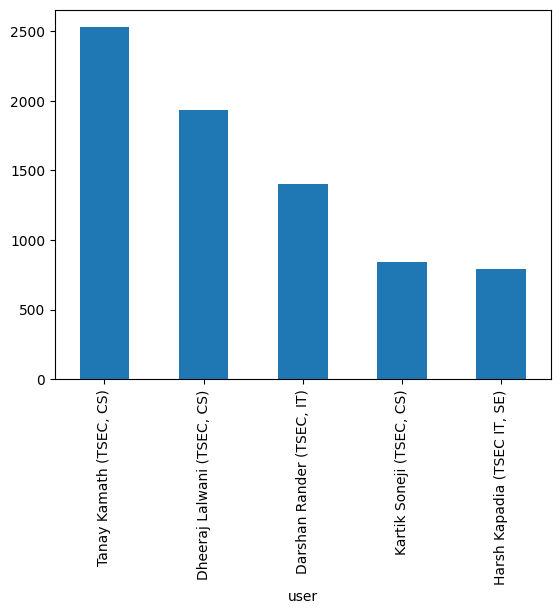

In [19]:
x.plot(kind='bar')


In [28]:
round((df['user'].value_counts()/df.shape[0])*100,2).reset_index().rename(columns={'index':'name','user':'percent'})

,percent,count
0,"Tanay Kamath (TSEC, CS)",18.90
1,"Dheeraj Lalwani (TSEC, CS)",14.48
2,"Darshan Rander (TSEC, IT)",10.49
3,"Kartik Soneji (TSEC, CS)",6.29
4,"Harsh Kapadia (TSEC IT, SE)",5.90
...,...,...
149,+91 96194 00980,0.01
150,+91 94200 70678,0.01
151,+91 98206 14506,0.01
152,+91 98199 01072,0.01


In [35]:
temp=df[df['user']!='group_notification']
temp=temp[temp['message']!='<Media omitted>\n']


In [38]:
f=open('stop_hinglish.txt','r')
stop_words=f.read()


In [44]:
words=[]
for message in temp['message']:
    for word in message.lower().split():
        if word not in stop_words:
            words.append(word)

In [46]:
from collections import Counter
pd.DataFrame(Counter(words).most_common(20), columns=['Word', 'Frequency'])

,Word,Frequency
0,😂,388
1,message,340
2,deleted,332
3,},266
4,=,232
5,😂😂,230
6,{,210
7,code,132
8,👍,110
9,java,101


In [48]:
df.head(2)

,date,user,message,year,month,day,hour,minute
113,2020-01-27 19:31:00,+91 96536 93868,<Media omitted>\n,2020,January,27,19,31
114,2020-01-27 19:31:00,+91 96536 93868,Give it a try ....\n,2020,January,27,19,31


In [ ]:
df['month_num']=df['date'].dt.month


,date,user,message,year,month,day,hour,minute,month_num
113,2020-01-27 19:31:00,+91 96536 93868,<Media omitted>\n,2020,January,27,19,31,1
114,2020-01-27 19:31:00,+91 96536 93868,Give it a try ....\n,2020,January,27,19,31,1


In [70]:
timeline=df.groupby(['year','month_num','month']).count()['message'].reset_index()
timeline.head()

,year,month_num,month,message
0,2020,1,January,339
1,2020,2,February,1992
2,2020,3,March,1739
3,2020,4,April,1246
4,2020,5,May,1290


In [71]:
time=[]
for i in range(timeline.shape[0]):
    time.append(timeline['month'][i]+"-"+str(timeline['year'][i]))

In [72]:
timeline['time']=time

In [73]:
timeline.head()

,year,month_num,month,message,time
0,2020,1,January,339,January-2020
1,2020,2,February,1992,February-2020
2,2020,3,March,1739,March-2020
3,2020,4,April,1246,April-2020
4,2020,5,May,1290,May-2020


In [75]:
import matplotlib.pyplot as plt

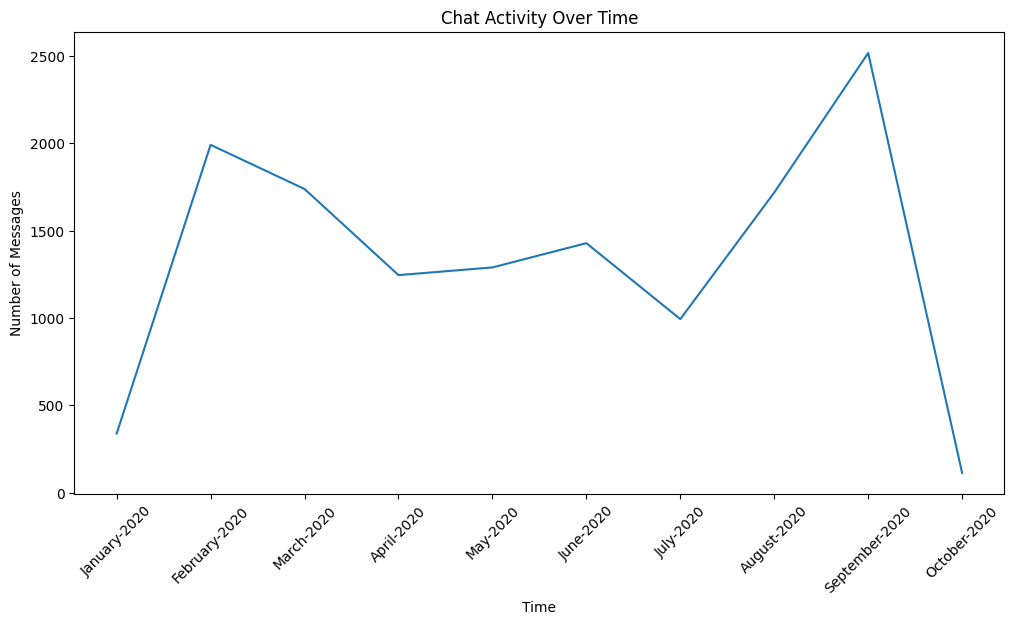

In [77]:
plt.figure(figsize=(12,6))
plt.plot(timeline['time'],timeline['message'])
plt.xticks(rotation=45)
plt.xlabel('Time')
plt.ylabel('Number of Messages')
plt.title('Chat Activity Over Time')
plt.show()